# DBSCAN Clustering Analysis
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering technqiue that groups data based on density rather than distance to a centroid. Additionally, this method does not require specifying the number of clusters in advance, as it can identify outliers. Using DBSCAN is useful when clusters have irregular shapre or do not belong to any clear group.

In [15]:
#uploading the data and importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [16]:
#loading data
df = pd.read_csv("/Users/muskaanmahes/Downloads/full_dataset.csv")

#features selected
features = ['CGPA', 'Internships', 'Projects', 'Certifications', 'Communication_Skills']
X = df[features]

#scaling features
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

# Parameter Selection (K-distance Plot)
The K-distance plot was used to determine a suitable value for eps, which is the radius that DBSCAN uses to decide whether points are close enough to belond to the same dense group. Here the plot shows the distance to the 10th nearest neighbor for each point. Additionally, the plot shows that the curve remaine flat for majority of the points, and then increased sharply towards the end. The "elbow" of the curve was around 0.3-0.4, therefore, eps = 0.35 was selected as it is in the middle of those ranges. A min_sample of 10 was chosen based on five features. Doing these steps ensured that the clusters represent sufficiently dense regions of the data. 

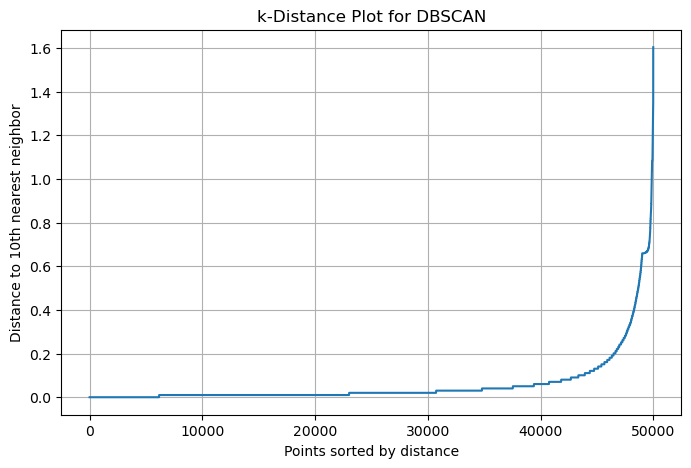

In [4]:
#k-distance plots for eps- radius DBSCAN uses to decide whether the pts are close
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_Scaled)
distances,indices = neighbors_fit.kneighbors(X_Scaled)

#Distance to the kth nearest neighbor
K_dist = np.sort(distances[:, -1])

#k-distance plot
plt.figure(figsize=(8, 5))
plt.plot(K_dist)
plt.title("k-Distance Plot for DBSCAN")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.grid(True)
plt.show()


# DBSCAN Results
After running the DBSCAN on the data, it summarized the results into 3 sections. The number of clusters that were identified were 190. The number of noise points deteced were 1,263, and there was about 2.53% of noise fraction. Therefore, this all means that the DBSCAN identified many clusters rather than large ones. Additionally, a small percentage of points were classified as noise, meaning that most students belong to some dense groups. Lastly, the larger number of clusters suggested that the data could contain small, tightly grouped students profiles rather than broad segments. 

In [19]:
#Fit DBSCAN
eps = 0.35
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_Scaled)

df["DBSCAN_Cluster"] = labels

#appending the cluster info
n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
noise_fraction = n_noise / len(labels)

print("Number of clusters:", n_cluster)
print("Number of noise points:", n_noise)
print("Noise fraction:", round(noise_fraction, 4))

Number of clusters: 190
Number of noise points: 1263
Noise fraction: 0.0253


# Cluster Sizes and Cluster Characteristics 
From the results, we found that the cluster sizes vary significantly. Some of the clusters were very large, for exmaple, there were 2,000 students. Other clusters were very small, such as, the less than 100 students that were detected. This indiciated that certain student profiules are very common through the large clusters, and others were rare through the small clusters. The presence of many small clusters reflects that the discrete nature of features like internships, projects, and certifications.

Additionally, we can detect pattern from the large clusters. Many clusters had a CGPA ranging from 6.5-7.2, 0 or 1 internships, 3 to 4 projects, 1 to 2 certifications, and communciation skills between 4 and 7. This suggest that the DBSCAN is grouping students with similar academic and skill profiles into dense regions. 

In [20]:
#Cluster sizes
cluster_sizes = pd.Series(labels).value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_sizes.head(20))

#cluster summaries
cluster_summary = (
    df[df["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")[features]
    .mean()
)

cluster_summary["size"] = (
    df[df["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")[features]
    .size()
)

print("\nTop 10 largest clusters:")
print(cluster_summary.sort_values(by="size", ascending=False).head(10))


Cluster sizes:
-1     1263
 0     2002
 1      499
 2     1859
 3      919
 4     1861
 5     1124
 6     1187
 7       64
 8       17
 9       54
 10     121
 11     611
 12     672
 13    1899
 14     435
 15     530
 16     117
 17     586
 18     579
Name: count, dtype: int64

Top 10 largest clusters:
                    CGPA  Internships  Projects  Certifications  \
DBSCAN_Cluster                                                    
44              7.147654          0.0       4.0             2.0   
23              7.149961          0.0       4.0             2.0   
0               6.526009          0.0       3.0             1.0   
13              6.545661          0.0       3.0             1.0   
4               7.211891          1.0       4.0             2.0   
2               7.201377          1.0       4.0             2.0   
53              7.181867          0.0       4.0             2.0   
22              7.131990          0.0       4.0             2.0   
25              6.5302

# External Validation with Placement Status
To evaluate the clustering results externally, the DBSCAN cluster labels were compared with the Placement_Status variable using Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI). From this computation, we got an ARI of 0.0152 which is very low. This could have happened because the clusters do not directly matched with the labels that are placed vs no placed. Additionally, we got a NMI of 0.1412 which is low but it is a non-zero. The clustering still captures some meaningful information related to placement. OVerall, the DBSCAN is simply is not seperating students into "placed" and "not placed", instead is captures more detailed patterns in the student profiles. 

# Placement Rates by Cluster
Looking at the placement rates within cluster there are some cluster with high placement of around 65% to 69%, while others have 0%. For example, clusters with higher CGPA of around 7.1-7.2 and at least 1 internship shows high placement rates. While clusters with lower CGPA of around 6.5 and no internships shows very low placement rates. This shows that clusters corresponds to meaningful difference in outcomes. 

In [22]:
#Using Placement_status after clustering after interpretation
if "Placement_Status" in df.columns:
    y_true = (df["Placement_Status"] == "Placed").astype(int)

#computing Adjusted rand index-measure how similar 2 groups are
    adjusted_rate_index = adjusted_rand_score(y_true, labels)
#computing normalized mutal info - measures the infor the cluster labels give 
    norm_mutual_info = normalized_mutual_info_score(y_true, labels)

    print("\nExternal comparison with Placement_Status")
    print("ARI:", round(adjusted_rate_index, 4))
    print("NMI:", round(norm_mutual_info, 4))

#compute placement rate inside each cluster 
    placement_by_cluster = (
        df[df["DBSCAN_Cluster"] != -1]
        .groupby("DBSCAN_Cluster")["Placement_Status"]
        .apply(lambda s: (s == "Placed").mean())
        .rename("placement_rate")
    )

#joining placement rate with cluster summary 
    final_summary = cluster_summary.join(placement_by_cluster)
    print("\nLargest clusters with placement rates:")
    print(final_summary.sort_values("size", ascending=False).head(10))




External comparison with Placement_Status
ARI: 0.0152
NMI: 0.1412

Largest clusters with placement rates:
                    CGPA  Internships  Projects  Certifications  \
DBSCAN_Cluster                                                    
44              7.147654          0.0       4.0             2.0   
23              7.149961          0.0       4.0             2.0   
0               6.526009          0.0       3.0             1.0   
13              6.545661          0.0       3.0             1.0   
4               7.211891          1.0       4.0             2.0   
2               7.201377          1.0       4.0             2.0   
53              7.181867          0.0       4.0             2.0   
22              7.131990          0.0       4.0             2.0   
25              6.530220          0.0       3.0             1.0   
30              6.527490          0.0       3.0             1.0   

                Communication_Skills  size  placement_rate  
DBSCAN_Cluster             

# PCA Visualization
The PCA plot shows the clusters in two dimensions. We can see that the points are spread across the space without clear large separations. The clusters overlap visually, indicating that separation occurs in higher dimensions. Also the horizontal banding pattern reflects the discrete nature of the features. Therefore, this confirms that DBSCAN is indentifying local density structures rather than large, visually seperable groups. 

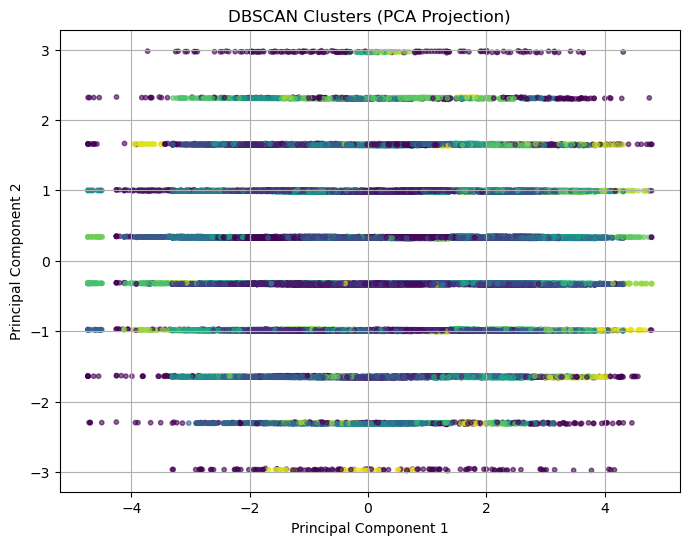

In [14]:
#PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_Scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=10,
    alpha=0.6
)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# Important Findings 
1. DBSCAN indentified many small, dense clusters indicating diverse student profiles.
2. Only a small percentage of students were classified as outliers.
3. Clusters will higher CGPA and internships tend to have significantly better placement outcomes.
4. Communication skills also appear to influence placement within clusters.
5. The clustering captures meaningful patterns, even though it does not directly align with placement labels.

Overall DBSCAN was effective in identifying detailed subgroups of students based on academic and skill-related features. It revealed meaningful local patterns and highlighted differences in placement outcomes across groups. Therefore, this makes DBSCAN useful for understanding the structure in the dataset. 